In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('OPDC_Discovery_PD_arm_longitudinal.csv' , low_memory=False)

In [72]:
for col in df.columns : 
    if 'updrs' in col.lower() : 
        print(col)

UPDRS_I
UPDRS_III
af_updrs_problem
UPDRS_IV
UPDRS_II


In [73]:
events = list(df['visit'].unique().astype(str))
x_list = pd.DataFrame(list(df['visit'].unique()) , index = events , columns=['response'])

In [74]:
p1_1_cols = list(df.columns[7:13])
p1_2_cols = list(df.columns[204:211])
p2_cols = list(df.columns[191:204])
p3_cols = list(df.columns[14:47])

In [75]:
ppmi_mds_updrs_p1_1 = pd.read_csv('./../../data/Assesment_Exams/MDS-UPDRS_Part_I_21Aug2023.csv')
ppmi_mds_updrs_p1_1_cols = [col for col in ppmi_mds_updrs_p1_1.columns if 'NP1' in col]

ppmi_mds_updrs_p1_2 = pd.read_csv('./../../data/Assesment_Exams/MDS-UPDRS_Part_I_Patient_Questionnaire_21Aug2023.csv')
ppmi_mds_updrs_p1_2_cols = [col for col in ppmi_mds_updrs_p1_2.columns if 'NP1' in col]

ppmi_mds_updrs_p2 = pd.read_csv('./../../data/Assesment_Exams/MDS_UPDRS_Part_II__Patient_Questionnaire_21Aug2023.csv')
ppmi_mds_updrs_p2_cols = [col for col in ppmi_mds_updrs_p2.columns if 'NP2' in col]

ppmi_mds_updrs_p3 = pd.read_csv('./../../data/Assesment_Exams/MDS-UPDRS_Part_III_21Aug2023.csv')
ppmi_mds_updrs_p3_cols = [col for col in ppmi_mds_updrs_p3.columns if 'NP3' in col]

ppmi_mds_updrs_p4 = pd.read_csv('./../../data/Assesment_Exams/MDS-UPDRS_Part_IV__Motor_Complications_21Aug2023.csv')
ppmi_mds_updrs_p4_cols = [col for col in ppmi_mds_updrs_p4.columns if 'NP4' in col]

In [76]:
df.head()

,subjid,visit,visit_type,age,disease_duration_diag,disease_duration_onset,UPDRS_I,ae_1_1_cognitive,ae_1_2_hallucin,ae_1_3_depressed,...,prn_4,prn_5,prn_6,prn_7,prn_8,prn_9,prn_10,prn_11,prn_12,prn_13
0,PDS/AH/002,1,doctor,69.1,1.7,2.4,3.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PDS/AH/002,2,doctor,70.6,3.2,3.9,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PDS/AH/002,3,doctor,72.3,4.9,5.6,11.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PDS/AH/002,4,telephone,73.9,6.5,7.2,5.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PDS/AH/002,5,telephone,75.5,8.1,8.8,13.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
p1_final = df[['subjid', 'visit'] + [col for col in p1_1_cols + p1_2_cols]]
p1_final.columns = ['subjid', 'visit'] + ppmi_mds_updrs_p1_1_cols[:-1] + ppmi_mds_updrs_p1_2_cols[:-1]
p1_final = p1_final.rename(columns = {'subjid' : 'PATNO', 'visit' : 'EVENT_ID'})

p1_final['EVENT_ID'] = p1_final['EVENT_ID'].astype(str)


p2_final = df[['subjid', 'visit'] + [col for col in p2_cols]]
p2_final.columns = ['subjid', 'visit'] + ppmi_mds_updrs_p2_cols[:-1]
p2_final = p2_final.rename(columns = {'subjid' : 'PATNO', 'visit' : 'EVENT_ID'} )
p2_final['EVENT_ID'] = p2_final['EVENT_ID'].astype(str)

p3_final = df[['subjid', 'visit'] + [col for col in p3_cols]]
p3_final.columns = ['subjid', 'visit'] + ppmi_mds_updrs_p3_cols[:-1]
p3_final = p3_final.rename(columns = {'subjid' : 'PATNO', 'visit' : 'EVENT_ID'})
p3_final['EVENT_ID'] = p3_final['EVENT_ID'].astype(str)

#p4_1 = mds_updrs[['ID', 'Visit'] + [col for col in mds_updrs.columns if '_IV_' in col]]
#p4_1.columns = ['ID', 'Visit'] + ppmi_mds_updrs_p4_cols

In [86]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p1_final['PATNO'].unique())) , 'PATNO' : np.repeat(p1_final['PATNO'].unique() , len(events))})

p1_final = p1_final[p1_final['EVENT_ID'].isin(events)]
p1_impute = pd.merge(all_tmpt , p1_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p1_impute['EVENT_ID'] = pd.Categorical(p1_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p1_impute['PATNO'].unique() : 
    row_na = False
    df = p1_impute[p1_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i , 2:].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p1_impute[p1_impute['PATNO'] == patno] = df.copy()

#p1 = p1_impute[np.logical_and(p1_impute['PATNO'].isin(idiopathic_ids) , p1_impute['EVENT_ID'].isin(events))]
p1 = p1_impute[p1_impute['EVENT_ID'].isin(events)]

In [87]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p2_final['PATNO'].unique())) , 'PATNO' : np.repeat(p2_final['PATNO'].unique() , len(events))})

p2_final = p2_final[p2_final['EVENT_ID'].isin(events)]
p2_impute = pd.merge(all_tmpt , p2_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p2_impute['EVENT_ID'] = pd.Categorical(p2_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p2_impute['PATNO'].unique() : 
    row_na = False
    df = p2_impute[p2_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i , 2:].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p2_impute[p2_impute['PATNO'] == patno] = df.copy()

#p2 = p2_impute[np.logical_and(p2_impute['PATNO'].isin(idiopathic_ids) , p2_impute['EVENT_ID'].isin(events))]
p2 = p2_impute[p2_impute['EVENT_ID'].isin(events)]

In [88]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p3_final['PATNO'].unique())) , 'PATNO' : np.repeat(p3_final['PATNO'].unique() , len(events))})

p3_final = p3_final[p3_final['EVENT_ID'].isin(events)]
p3_impute = pd.merge(all_tmpt , p3_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p3_impute['EVENT_ID'] = pd.Categorical(p3_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p3_impute['PATNO'].unique() : 
    row_na = False
    df = p3_impute[p3_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i , 2:].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p3_impute[p3_impute['PATNO'] == patno] = df.copy()

#p3 = p3_impute[np.logical_and(p3_impute['PATNO'].isin(idiopathic_ids) , p3_impute['EVENT_ID'].isin(events))]
p3 = p3_impute[p3_impute['EVENT_ID'].isin(events)]

Eigenvalues: [8.79736333 4.01131795 2.48819832 1.85030891 1.52188727 1.27207916
 1.15904835 0.96556335 0.83922977 0.80792821 0.80134252 0.68903488
 0.6214698  0.58728298 0.55462076 0.52274643 0.5108818  0.47034536
 0.46318883 0.4363282  0.42816655 0.40762398 0.37307255 0.36121202
 0.34097769 0.29092926 0.25387031 0.24877378 0.21021148 0.20381793
 0.17905134 0.1685673  0.16355962]


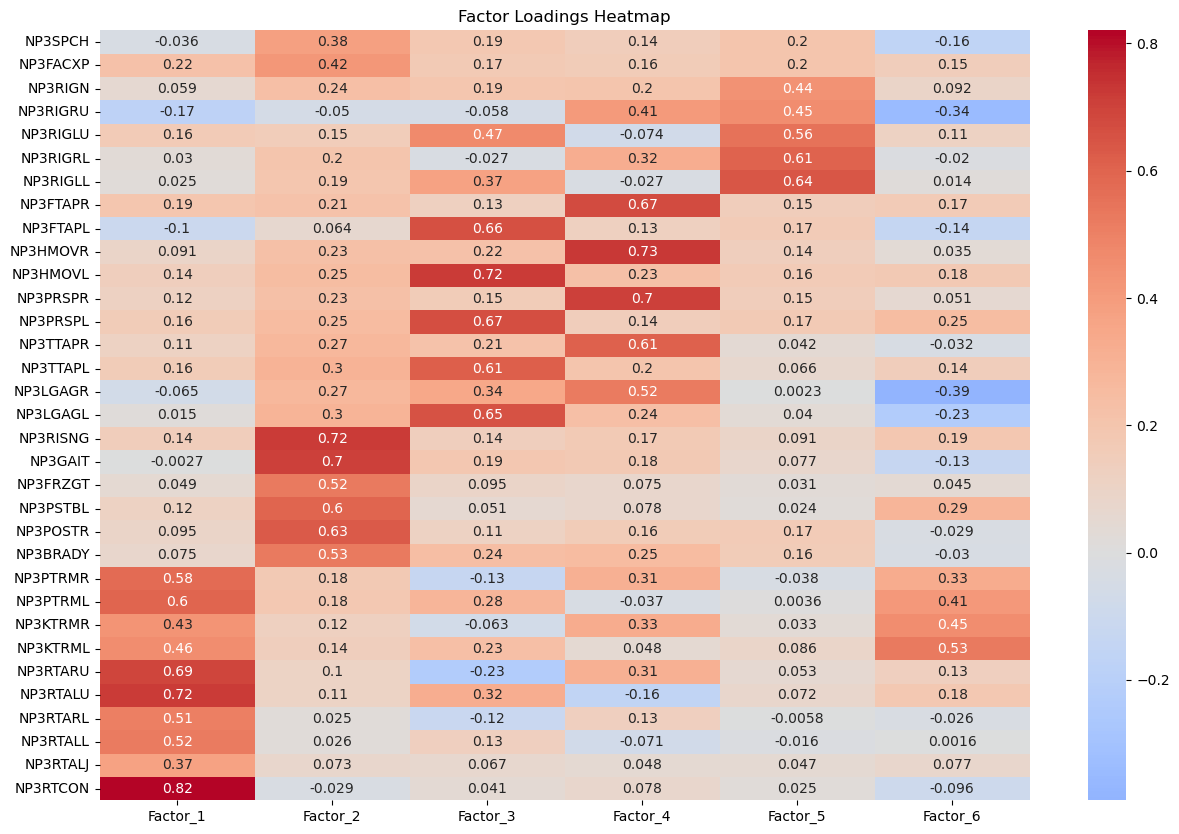

['fa_model_P3.joblib']

In [103]:
from factor_analyzer import FactorAnalyzer
import joblib

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=6, rotation="varimax")

# Fit the model
fa.fit(p3.iloc[: , 2:])
p3_cols = p3.iloc[: , 2:].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p3.iloc[: , 2:].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P3_')

factor_scores_df['PATNO'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['EVENT_ID']
p3_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p3_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(15, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()
joblib.dump({"fa": fa}, "fa_model_P3.joblib")

Eigenvalues: [5.41284945 1.12744823 1.03018089 0.95952345 0.76046574 0.66494651
 0.58671005 0.528546   0.45461693 0.44718364 0.41643945 0.31589883
 0.29519086]


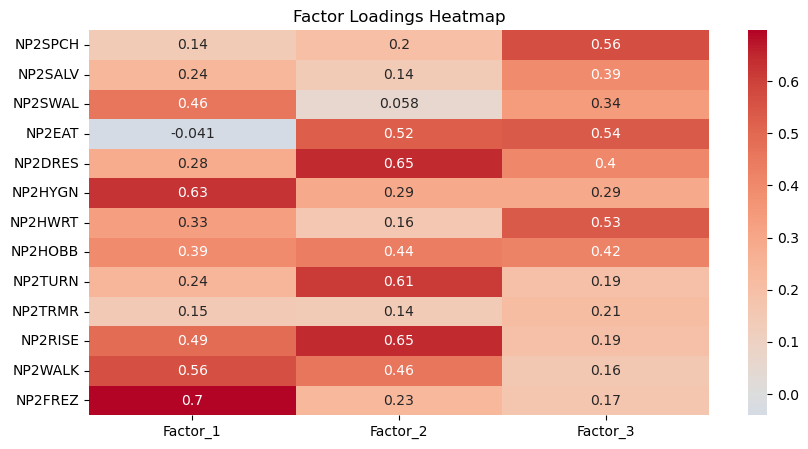

['fa_model_P2.joblib']

In [104]:
from factor_analyzer import FactorAnalyzer
import joblib

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=3, rotation="varimax")

# Fit the model
fa.fit(p2.iloc[: , 2:])
p2_cols = p2.iloc[: , 2:].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p2.iloc[: , 2:].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P2_')

factor_scores_df['PATNO'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['EVENT_ID']
p2_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p2_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

joblib.dump({"fa": fa}, "fa_model_P2.joblib")

Eigenvalues: [3.88308135 1.76748332 0.97161109 0.95043718 0.84580626 0.76386891
 0.70283752 0.66278414 0.56003251 0.52324643 0.51046652 0.46953262
 0.38881216]


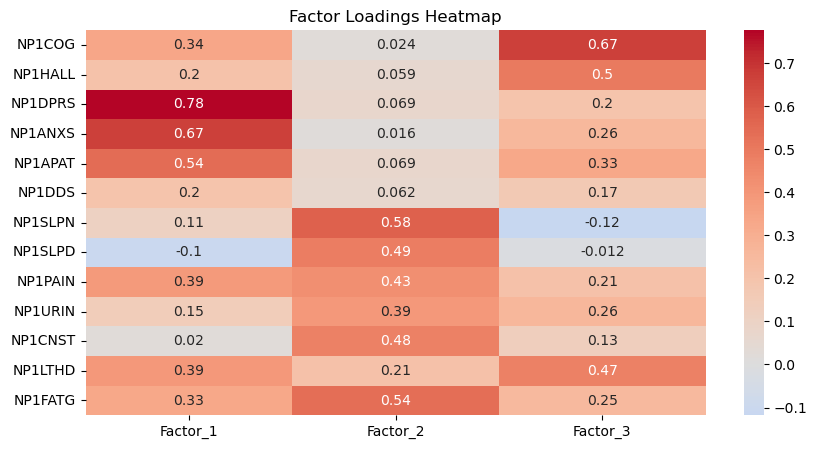

['fa_model_P1.joblib']

In [105]:
from factor_analyzer import FactorAnalyzer
import joblib

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=3, rotation="varimax")

# Fit the model
fa.fit(p1.iloc[: , 2:])
p1_cols = p1.iloc[: , 2:].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p1.iloc[: , 2:].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P1_')

factor_scores_df['PATNO'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['EVENT_ID']
p1_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p1_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

joblib.dump({"fa": fa}, "fa_model_P1.joblib")

In [106]:
tmp = pd.merge(p1_FA , p2_FA , on = ['PATNO' , 'EVENT_ID'])
final = pd.merge(tmp , p3_FA , on = ['PATNO' , 'EVENT_ID'])

In [107]:
final.to_csv('./FA_MDS-UPDRS_FROM_OPDC.csv')